In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

In [7]:
def get_Arbitrum_prices(days=365):
    url = f"https://api.coingecko.com/api/v3/coins/arbitrum/market_chart?vs_currency=usd&days={days}"
    response = requests.get(url)
    data = response.json()["prices"]
    return np.array(data)

# Fetch the last 365 days of Ethereum prices
data = get_Arbitrum_prices(days=365)

# Create a DataFrame from the fetched data and set a date index
df = pd.DataFrame(data) # Create DataFrame
df['date'] = pd.date_range(end=pd.Timestamp.today(), periods=len(data), freq='D') # Generate dates
df = df.set_index('date') # Set date as index

df = df.asfreq('D')  # Ensure daily frequency and handle missing dates if any
df.to_csv('arbitrum_prices.csv')

In [3]:
def get_Chainlink_prices(days=365):
    url = f"https://api.coingecko.com/api/v3/coins/chainlink/market_chart?vs_currency=usd&days={days}"
    response = requests.get(url)
    data = response.json()["prices"]
    return np.array([price[1] for price in data])

# Fetch the last 365 days of Ethereum prices
data = get_Chainlink_prices(days=365)

# Create a DataFrame from the fetched data and set a date index
df = pd.DataFrame(data, columns=['price']) # Create DataFrame
df['date'] = pd.date_range(end=pd.Timestamp.today(), periods=len(data), freq='D') # Generate dates
df = df.set_index('date') # Set date as index

df = df.asfreq('D')  # Ensure daily frequency and handle missing dates if any
df.to_csv('chainlink_prices.csv')

In [4]:


def get_ethereum_prices(days=365):
    url = f"https://api.coingecko.com/api/v3/coins/ethereum/market_chart?vs_currency=usd&days={days}"
    response = requests.get(url)
    data = response.json()["prices"]
    return np.array([price[1] for price in data])

# Fetch the last 365 days of Ethereum prices
data = get_ethereum_prices(days=365)

# Create a DataFrame from the fetched data and set a date index
df = pd.DataFrame(data, columns=['price']) # Create DataFrame
df['date'] = pd.date_range(end=pd.Timestamp.today(), periods=len(data), freq='D') # Generate dates
df = df.set_index('date') # Set date as index

df = df.asfreq('D')  # Ensure daily frequency and handle missing dates if any
df.to_csv('ethereum_prices.csv')

In [6]:
!pip install statsmodels

In [ ]:

from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# Split the data into train, validation, and test sets
train_size = int(len(df) * 0.8)
val_size = int(len(df) * 0.1)
test_size = len(df) - train_size - val_size

train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:train_size+val_size]
test_data = df.iloc[train_size+val_size:]

# Preprocess the data
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data[['price']])
val_data_scaled = scaler.transform(val_data[['price']])
test_data_scaled = scaler.transform(test_data[['price']])

# Grid search for SARIMA hyperparameters
p = d = q = range(0, 3)
pdq = list(product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in pdq]

best_aic = float("inf")
best_params = None

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = SARIMAX(train_data['price'], order=param, seasonal_order=param_seasonal, enforce_stationarity=False, enforce_invertibility=False)
            results = mod.fit()
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = (param, param_seasonal)
        except:
            continue

print("Best SARIMA Parameters:", best_params)

# Create and fit SARIMA model with explicit frequency
best_order, best_seasonal_order = best_params
model = SARIMAX(train_data['price'], order=best_order, seasonal_order=best_seasonal_order)
model_fit = model.fit()

# Make 7-day forecast with explicit frequency
forecast = model_fit.forecast(steps=7)
forecast_data = forecast.values
actual_data = test_data['price'].values[:7]
forecast_dates = pd.date_range(start=test_data.index[0], periods=7)

# Evaluate the model
mae = mean_absolute_error(actual_data, forecast_data)
mse = mean_squared_error(actual_data, forecast_data)
r2 = r2_score(actual_data, forecast_data)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Plot the actual and forecast data for the last 3 months
plt.figure(figsize=(12, 6))
plt.plot(test_data.index[:7], actual_data, label='Actual')
plt.plot(forecast_dates, forecast_data, label='Forecast')
plt.title('Ethereum Price Forecast (Last 3 Months)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Plot the actual and forecast data for the last 12 months
plt.figure(figsize=(12, 6))
plt.plot(test_data.index[:30], test_data['price'].values[:30], label='Actual')
plt.plot(test_data.index[:30], model_fit.forecast(steps=30), label='Forecast')
plt.title('Ethereum Price Forecast (Last 12 Months)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

In [ ]:

pip install pystan
pip install fbprophet

Error: Error fetching data: 401 - {"error":{"status":{"timestamp":"2024-04-14T20:21:49.032+00:00","error_code":10012,"error_message":"Your request exceeds the allowed time range. Public API users are limited to querying historical data within the past 365 days. Upgrade to a paid plan to enjoy full historical data access: https://www.coingecko.com/en/api/pricing. "}}}
Ethereum Price Data (Last 366 days):
                                  Price
Date                                   
2023-04-15 20:21:49.173091  2093.166331
2023-04-16 20:21:49.173091  2118.598789
2023-04-17 20:21:49.173091  2077.535665
2023-04-18 20:21:49.173091  2103.278814
2023-04-19 20:21:49.173091  1936.425921

Descriptive Statistics:
             Price
count   366.000000
mean   2182.624973
std     614.584267
min    1536.812805
25%    1805.148240
50%    1899.778956
75%    2330.507488
max    4070.604075


<Figure size 1200x600 with 0 Axes>

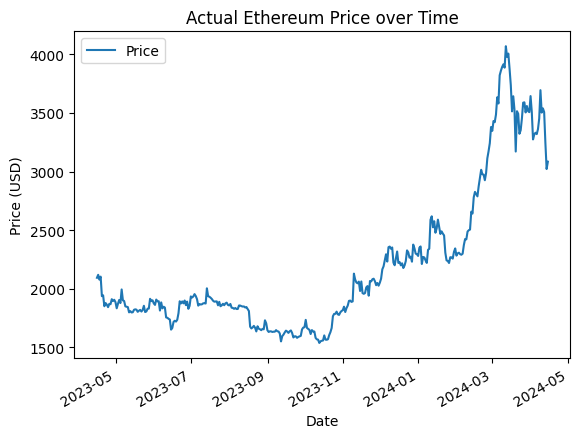

Epoch 1/100
11/11 [==============================] - 3s 7ms/step - loss: 0.1062
Epoch 2/100
11/11 [==============================] - 0s 7ms/step - loss: 0.0895
Epoch 3/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0736
Epoch 4/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0586
Epoch 5/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0464
Epoch 6/100
11/11 [==============================] - 0s 5ms/step - loss: 0.0382
Epoch 7/100
11/11 [==============================] - 0s 4ms/step - loss: 0.0309
Epoch 8/100
11/11 [==============================] - 0s 4ms/step - loss: 0.0259
Epoch 9/100
11/11 [==============================] - 0s 4ms/step - loss: 0.0219
Epoch 10/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0193
Epoch 11/100
11/11 [==============================] - 0s 6ms/step - loss: 0.0171
Epoch 12/100
11/11 [==============================] - 0s 5ms/step - loss: 0.0156
Epoch 13/100
11/11 [=================

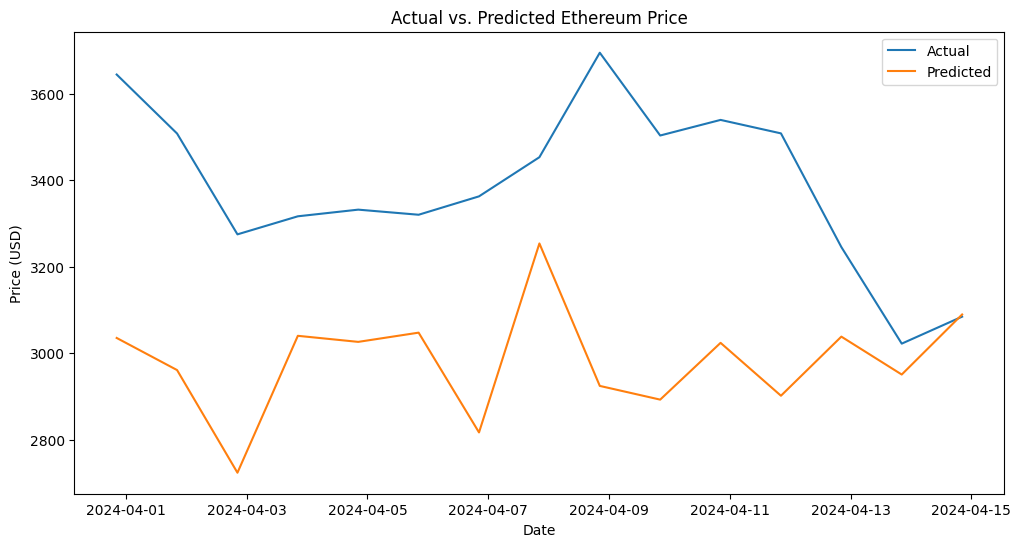


Predicted Ethereum Prices for the Next 15 Days:
2024-04-15: $3035.15
2024-04-16: $2960.85
2024-04-17: $2723.28
2024-04-18: $3040.10
2024-04-19: $3026.08
2024-04-20: $3047.43
2024-04-21: $2816.51
2024-04-22: $3253.85
2024-04-23: $2924.18
2024-04-24: $2892.43
2024-04-25: $3023.83
2024-04-26: $2901.46
2024-04-27: $3038.23
2024-04-28: $2950.50
2024-04-29: $3089.47


In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
import requests
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

data = pd.read_csv('/content/ethereum_prices.csv.csv', index_col='Date')
# Fetch the Ethereum price data
num_days_to_fetch = 366  # Change this value to adjust the number of days to fetch
try:
    data = get_ethereum_prices(days=num_days_to_fetch)
except (KeyError, requests.exceptions.RequestException) as e:
    print(f"Error: {e}")
    exit(1)

# Exploratory Data Analysis (EDA)
df = pd.DataFrame(data, columns=["Price"])
end_date = pd.Timestamp.today()
start_date = end_date - timedelta(days=num_days_to_fetch-1)
df["Date"] = pd.date_range(start=start_date, end=end_date, freq="D")
df = df.set_index("Date")

print(f"Ethereum Price Data (Last {num_days_to_fetch} days):")
print(df.head())
print("\nDescriptive Statistics:")
print(df.describe())

# Plot the actual Ethereum prices
plt.figure(figsize=(12, 6))
df.plot()
plt.title("Actual Ethereum Price over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data.reshape(-1, 1))

# Prepare the dataset
num_days_to_predict = 15  # Change this value to adjust the number of days to predict
X = []
y = []
for i in range(len(data_normalized)-num_days_to_predict):
    X.append(data_normalized[i:i+num_days_to_predict-1])
    y.append(data_normalized[i+1:i+num_days_to_predict])

X = np.array(X)
y = np.array(y)

# Reshape the input for LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Define the LSTM model
model = Sequential()
model.add(LSTM(30, input_shape=(num_days_to_predict-1, 1), return_sequences=True))
model.add(Dense(num_days_to_predict, activation='linear'))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
model.fit(X, y, epochs=100, batch_size=32, verbose=1)

# Make predictions
last_days = data_normalized[-num_days_to_predict+1:].reshape(1, num_days_to_predict-1, 1)
predictions = scaler.inverse_transform(model.predict(last_days).reshape(-1, num_days_to_predict))

# Plot the actual vs. predicted Ethereum prices
plt.figure(figsize=(12, 6))
plt.plot(df.index[-num_days_to_predict:], df["Price"][-num_days_to_predict:], label="Actual")
plt.plot(df.index[-num_days_to_predict:], predictions[0], label="Predicted")
plt.title("Actual vs. Predicted Ethereum Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

# Output the predicted prices for the next 15 days
print(f"\nPredicted Ethereum Prices for the Next {num_days_to_predict} Days:")
for i, price in enumerate(predictions[0], start=1):
    next_date = end_date + timedelta(days=i)
    print(f"{next_date.strftime('%Y-%m-%d')}: ${price:.2f}")

Error: Error fetching data: 401 - {"error":{"status":{"timestamp":"2024-04-14T20:32:38.534+00:00","error_code":10012,"error_message":"Your request exceeds the allowed time range. Public API users are limited to querying historical data within the past 365 days. Upgrade to a paid plan to enjoy full historical data access: https://www.coingecko.com/en/api/pricing. "}}}
Ethereum Price Data (Last 366 days):
                                  Price
Date                                   
2023-04-15 20:32:38.656183  2093.166331
2023-04-16 20:32:38.656183  2118.598789
2023-04-17 20:32:38.656183  2077.535665
2023-04-18 20:32:38.656183  2103.278814
2023-04-19 20:32:38.656183  1936.425921

Descriptive Statistics:
             Price
count   366.000000
mean   2182.624973
std     614.584267
min    1536.812805
25%    1805.148240
50%    1899.778956
75%    2330.507488
max    4070.604075


<Figure size 1200x600 with 0 Axes>

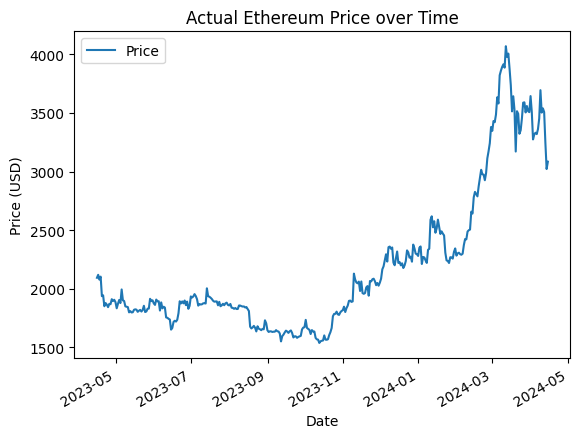

Epoch 1/100
11/11 [==============================] - 5s 66ms/step - loss: 0.0470
Epoch 2/100
11/11 [==============================] - 1s 69ms/step - loss: 0.0149
Epoch 3/100
11/11 [==============================] - 1s 68ms/step - loss: 0.0066
Epoch 4/100
11/11 [==============================] - 1s 68ms/step - loss: 0.0046
Epoch 5/100
11/11 [==============================] - 1s 100ms/step - loss: 0.0038
Epoch 6/100
11/11 [==============================] - 1s 87ms/step - loss: 0.0033
Epoch 7/100
11/11 [==============================] - 1s 69ms/step - loss: 0.0035
Epoch 8/100
11/11 [==============================] - 1s 68ms/step - loss: 0.0029
Epoch 9/100
11/11 [==============================] - 1s 67ms/step - loss: 0.0031
Epoch 10/100
11/11 [==============================] - 1s 68ms/step - loss: 0.0032
Epoch 11/100
11/11 [==============================] - 1s 69ms/step - loss: 0.0031
Epoch 12/100
11/11 [==============================] - 1s 69ms/step - loss: 0.0032
Epoch 13/100
11/11 [====

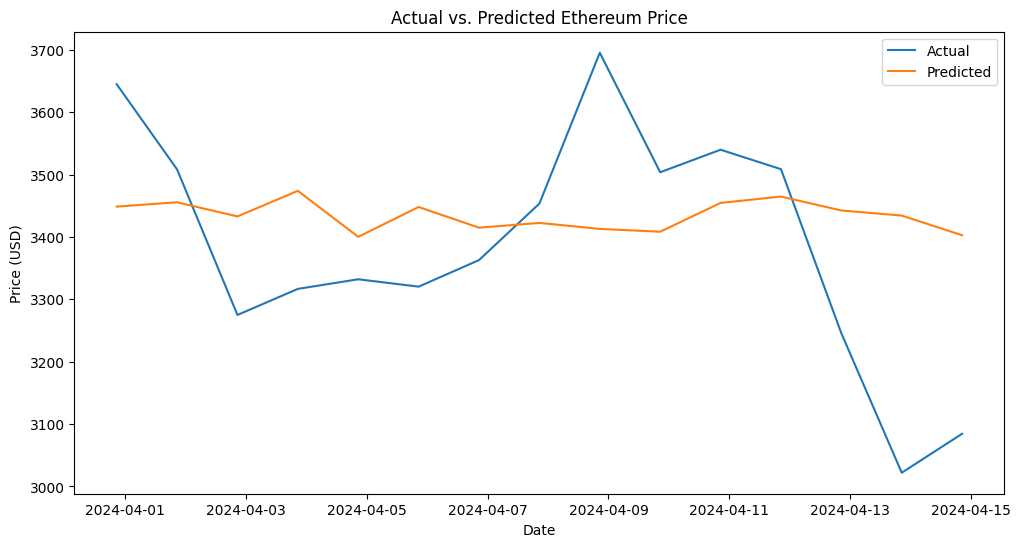


Predicted Ethereum Prices for the Next 15 Days:
2024-04-15: $3448.58
2024-04-16: $3455.51
2024-04-17: $3432.84
2024-04-18: $3473.87
2024-04-19: $3400.10
2024-04-20: $3447.97
2024-04-21: $3414.78
2024-04-22: $3422.41
2024-04-23: $3412.83
2024-04-24: $3408.32
2024-04-25: $3454.47
2024-04-26: $3464.68
2024-04-27: $3442.36
2024-04-28: $3434.20
2024-04-29: $3402.68


In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
import requests
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

data =
num_days_to_fetch = 366

# Exploratory Data Analysis (EDA)
df = pd.DataFrame(data, columns=["Price"])
end_date = pd.Timestamp.today()
start_date = end_date - timedelta(days=num_days_to_fetch-1)
df["Date"] = pd.date_range(start=start_date, end=end_date, freq="D")
df = df.set_index("Date")
print(f"Ethereum Price Data (Last {num_days_to_fetch} days):")
print(df.head())
print("\nDescriptive Statistics:")
print(df.describe())

# Plot the actual Ethereum prices
plt.figure(figsize=(12, 6))
df.plot()
plt.title("Actual Ethereum Price over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

# Normalize the data
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data.reshape(-1, 1))

# Prepare the dataset
num_days_to_predict = 15
X = []
y = []
for i in range(len(data_normalized)-num_days_to_predict):
    X.append(data_normalized[i:i+num_days_to_predict])
    y.append(data_normalized[i+1:i+num_days_to_predict+1])
X = np.array(X)
y = np.array(y)

# Reshape the input for LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Define the LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(num_days_to_predict, 1), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(256, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(num_days_to_predict, activation='linear'))
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
model.fit(X, y, epochs=100, batch_size=32, verbose=1)

# Make predictions
last_days = data_normalized[-num_days_to_predict:].reshape(1, num_days_to_predict, 1)
predictions = scaler.inverse_transform(model.predict(last_days))

# Plot the actual vs. predicted Ethereum prices
plt.figure(figsize=(12, 6))
plt.plot(df.index[-num_days_to_predict:], df["Price"][-num_days_to_predict:], label="Actual")
plt.plot(df.index[-num_days_to_predict:], predictions[0], label="Predicted")
plt.title("Actual vs. Predicted Ethereum Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

# Output the predicted prices for the next 15 days
print(f"\nPredicted Ethereum Prices for the Next {num_days_to_predict} Days:")
for i, price in enumerate(predictions[0], start=1):
    next_date = end_date + timedelta(days=i)
    print(f"{next_date.strftime('%Y-%m-%d')}: ${price:.2f}")

<ipython-input-37-0b140223435a>:12: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df.index = pd.to_datetime(df.index)
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0ecmyv5j/2l_8elya.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0ecmyv5j/trtjrql7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=45270', 'data', 'file=/tmp/tmp0ecmyv5j/2l_8elya.json', 'init=/tmp/tmp0ecmyv5j/trtjrql7.json', 'output', 'file=/tmp/tmp0ecmyv5j/prophet_model2c9fqzhq/prophet_model-20240415180726.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:07:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:07:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Train MAE: 20.08
Train MSE: 928.12
Train R-squared: 1.00
Test MAE: 42.80
Test MSE: 1918.28
Test R-squared: 0.95
7-Day Ethereum Price Forecast:
             ds         yhat   yhat_lower   yhat_upper
1553 2024-04-16  3233.730812  3192.765041  3272.351113
1554 2024-04-17  3235.075236  3194.826121  3274.802885
1555 2024-04-18  3230.976148  3188.774787  3267.516809
1556 2024-04-19  3235.919536  3193.920634  3275.578818
1557 2024-04-20  3239.069490  3199.602098  3277.073285
1558 2024-04-21  3244.839020  3206.221942  3286.178575
1559 2024-04-22  3244.516736  3204.241447  3287.514407


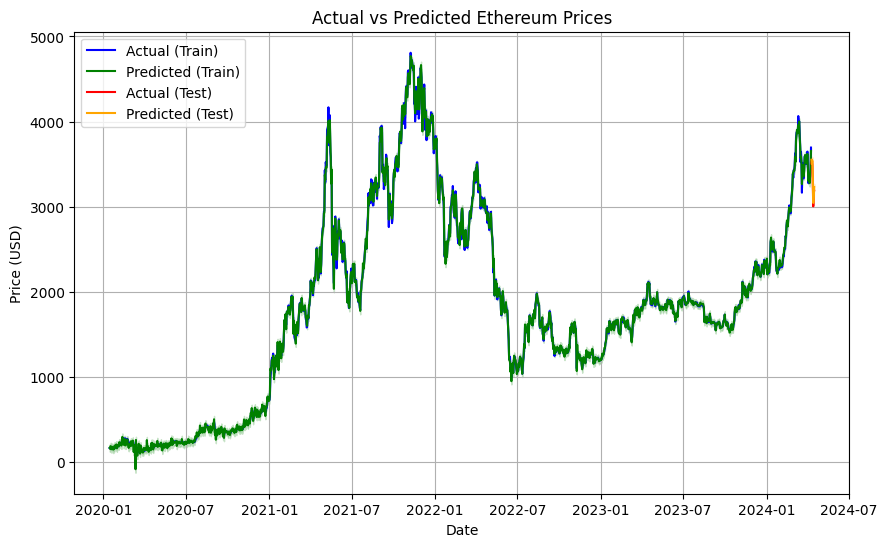

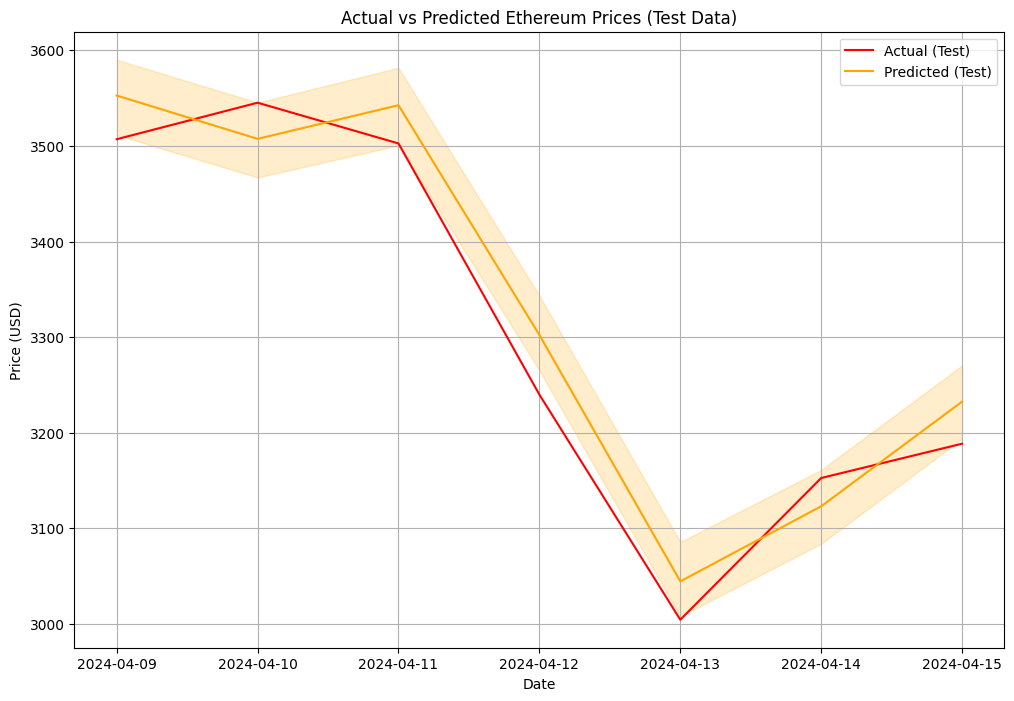

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load Ethereum price data from CSV
df = pd.read_csv('/content/Ethereum Historical Data.csv', index_col='Date')

# Reverse the order of dates
df = df.reindex(index=df.index[::-1])
df.index = pd.to_datetime(df.index)

# Prepare the data for Prophet
df_prophet = df.reset_index()
df_prophet = df_prophet.rename(columns={'Date': 'ds', 'Price': 'y', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Vol.': 'volume', 'Change %': 'change_percent'})
df_prophet['y'] = df_prophet['y'].str.replace(',', '').astype(float)
df_prophet['open'] = df_prophet['open'].str.replace(',', '').astype(float)
df_prophet['high'] = df_prophet['high'].str.replace(',', '').astype(float)
df_prophet['low'] = df_prophet['low'].str.replace(',', '').astype(float)

import re

def convert_volume(value):
    if isinstance(value, str):
        if value.endswith('M'):
            return float(value[:-1]) * 1e6
        elif value.endswith('K'):
            return float(value[:-1]) * 1e3
        elif value.endswith('B'):
            return float(value[:-1]) * 1e9
        else:
            return float(value)
    else:
        return value

df_prophet['volume'] = df_prophet['volume'].apply(convert_volume)
df_prophet['change_percent'] = df_prophet['change_percent'].str.replace('%', '').str.replace(',', '').astype(float)

# Create the Prophet model
model = Prophet(
    changepoint_prior_scale=10,
    holidays_prior_scale=15,
    seasonality_mode='multiplicative',
    seasonality_prior_scale=30,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)

# Add custom holidays
model.add_country_holidays(country_name='US')

# Add regressors
model.add_regressor('open')
model.add_regressor('high')
model.add_regressor('low')
model.add_regressor('volume')
model.add_regressor('change_percent')

# Fit the model
df_prophet = df_prophet.dropna()
model.fit(df_prophet)

# Make 7-day future predictions
future = model.make_future_dataframe(periods=7)
future['open'] = df_prophet['open'].iloc[-1]
future['high'] = df_prophet['high'].iloc[-1]
future['low'] = df_prophet['low'].iloc[-1]
future['volume'] = df_prophet['volume'].iloc[-1]
future['change_percent'] = df_prophet['change_percent'].iloc[-1]
forecast = model.predict(future)

# Evaluate the model
train_data = df_prophet[:-7]
test_data = df_prophet[-7:]
train_forecast = model.predict(train_data)
test_forecast = model.predict(test_data)

train_mae = mean_absolute_error(train_data['y'], train_forecast['yhat'])
train_mse = mean_squared_error(train_data['y'], train_forecast['yhat'])
train_r2 = r2_score(train_data['y'], train_forecast['yhat'])

test_mae = mean_absolute_error(test_data['y'], test_forecast['yhat'])
test_mse = mean_squared_error(test_data['y'], test_forecast['yhat'])
test_r2 = r2_score(test_data['y'], test_forecast['yhat'])

print(f"Train MAE: {train_mae:.2f}")
print(f"Train MSE: {train_mse:.2f}")
print(f"Train R-squared: {train_r2:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Test R-squared: {test_r2:.2f}")

# Display the 7-day forecast
print("7-Day Ethereum Price Forecast:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']][-7:])

# Plot actual vs predicted data for the training and test data
plt.figure(figsize=(10, 6))
plt.plot(train_data['ds'], train_data['y'], label='Actual (Train)', color='blue')
plt.plot(train_data['ds'], train_forecast['yhat'], label='Predicted (Train)', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual (Test)', color='red')
plt.plot(test_data['ds'], test_forecast['yhat'], label='Predicted (Test)', color='orange')
plt.fill_between(train_data['ds'], train_forecast['yhat_lower'], train_forecast['yhat_upper'], color='green', alpha=0.2)
plt.fill_between(test_data['ds'], test_forecast['yhat_lower'], test_forecast['yhat_upper'], color='orange', alpha=0.2)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Actual vs Predicted Ethereum Prices')
plt.legend()
plt.grid(True)
plt.show()

# Plot actual vs predicted data for the test data only
plt.figure(figsize=(12, 8))
plt.plot(test_data['ds'], test_data['y'], label='Actual (Test)', color='red')
plt.plot(test_data['ds'], test_forecast['yhat'], label='Predicted (Test)', color='orange')
plt.fill_between(test_data['ds'], test_forecast['yhat_lower'], test_forecast['yhat_upper'], color='orange', alpha=0.2)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.title('Actual vs Predicted Ethereum Prices (Test Data)')
plt.legend()
plt.grid(True)
plt.show()


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/254e4c51.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/qbjeznol.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=35727', 'data', 'file=/tmp/tmpg0uetom7/254e4c51.json', 'init=/tmp/tmpg0uetom7/qbjeznol.json', 'output', 'file=/tmp/tmpg0uetom7/prophet_modelvvpzpok2/prophet_model-20240416073206.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:32:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:32:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Train MAE: 20.08
Train MSE: 928.12
Train R-squared: 1.00
Test MAE: 42.80
Test MSE: 1918.28
Test R-squared: 0.95


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/oci27xp7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/7be7vy7k.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=34087', 'data', 'file=/tmp/tmpg0uetom7/oci27xp7.json', 'init=/tmp/tmpg0uetom7/7be7vy7k.json', 'output', 'file=/tmp/tmpg0uetom7/prophet_modelumvhtd2u/prophet_model-20240416073219.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:32:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:32:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Train MAE: 0.01
Train MSE: 0.00
Train R-squared: 1.00
Test MAE: 0.01
Test MSE: 0.00
Test R-squared: 0.99


DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/e9p3iiiq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/x_xd_hj8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19207', 'data', 'file=/tmp/tmpg0uetom7/e9p3iiiq.json', 'init=/tmp/tmpg0uetom7/x_xd_hj8.json', 'output', 'file=/tmp/tmpg0uetom7/prophet_model_i9__jae/prophet_model-20240416073223.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:32:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:32:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Train MAE: 0.11
Train MSE: 0.02
Train R-squared: 1.00
Test MAE: 0.18
Test MSE: 0.04
Test R-squared: 0.99


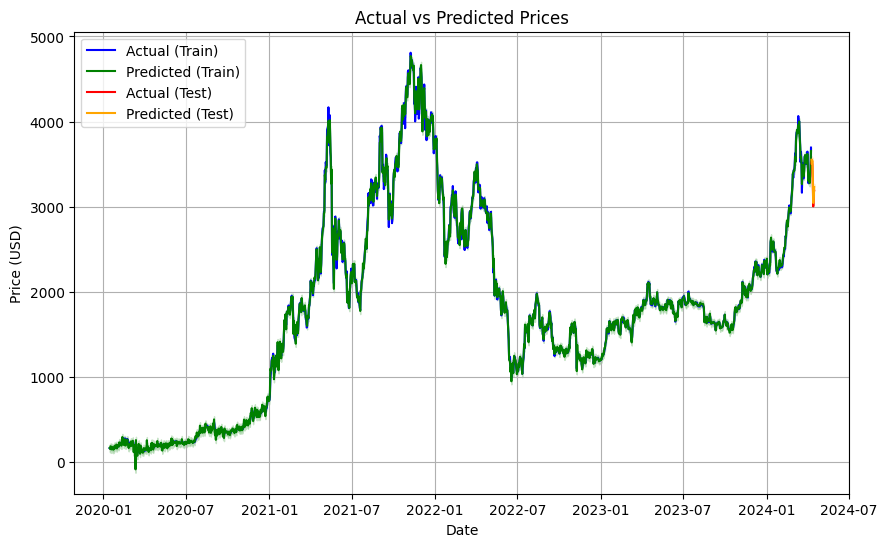

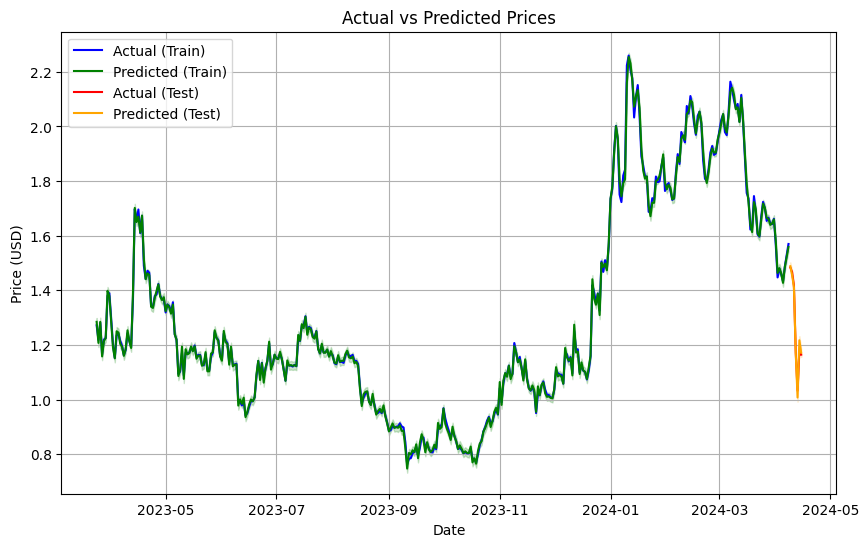

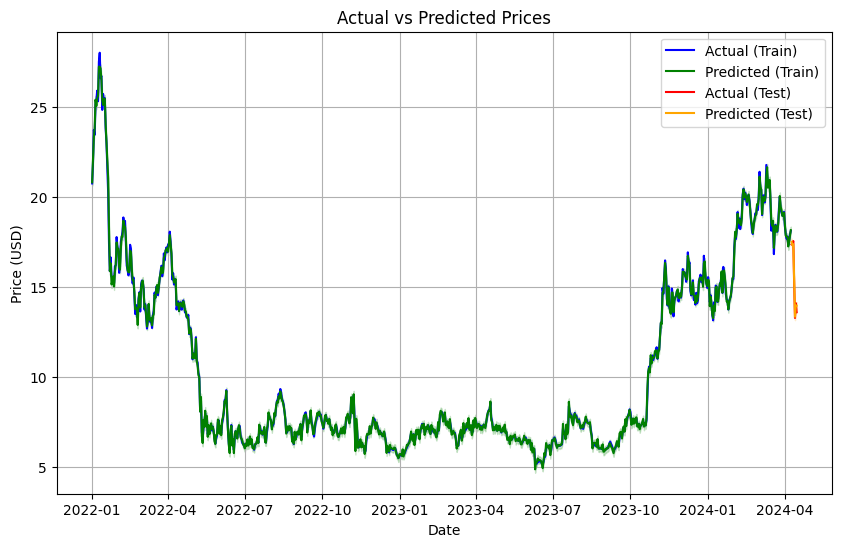

7-Day Ethereum Price Forecast:
             ds         yhat price_range
1553 2024-04-16  3233.730812   3225-3250
1554 2024-04-17  3235.075236   3225-3250
1555 2024-04-18  3230.976148   3225-3250
1556 2024-04-19  3235.919536   3225-3250
1557 2024-04-20  3239.069490   3250-3275
1558 2024-04-21  3244.839020   3250-3275
1559 2024-04-22  3244.516736   3250-3275

7-Day Arbitrum Price Forecast:
            ds      yhat price_range
389 2024-04-16  1.165748        0-25
390 2024-04-17  1.165940        0-25
391 2024-04-18  1.160503        0-25
392 2024-04-19  1.158264        0-25
393 2024-04-20  1.160130        0-25
394 2024-04-21  1.158269        0-25
395 2024-04-22  1.160528        0-25

7-Day Chainlink Price Forecast:
            ds       yhat price_range
836 2024-04-16  13.911619       25-50
837 2024-04-17  13.968255       25-50
838 2024-04-18  13.936080       25-50
839 2024-04-19  13.971768       25-50
840 2024-04-20  13.991804       25-50
841 2024-04-21  14.017027       25-50
842 2024-04-22

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

def load_data(file_path):
    df = pd.read_csv(file_path, index_col='Date', parse_dates=['Date'], dayfirst=True)
    df = df.reindex(index=df.index[::-1])
    return df

def prepare_data(df):
    df_prophet = df.reset_index()
    df_prophet = df_prophet.rename(columns={'Date': 'ds', 'Price': 'y', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Vol.': 'volume', 'Change %': 'change_percent'})

    # Convert columns to the correct data types
    df_prophet['y'] = df_prophet['y'].astype(str).str.replace(',', '').astype(float)
    df_prophet['open'] = df_prophet['open'].astype(str).str.replace(',', '').astype(float)
    df_prophet['high'] = df_prophet['high'].astype(str).str.replace(',', '').astype(float)
    df_prophet['low'] = df_prophet['low'].astype(str).str.replace(',', '').astype(float)


    import re

    def convert_volume(value):
        if isinstance(value, str):
            if value.endswith('M'):
                return float(value[:-1]) * 1e6
            elif value.endswith('K'):
                return float(value[:-1]) * 1e3
            elif value.endswith('B'):
                return float(value[:-1]) * 1e9
            else:
                return float(value)
        else:
            return value

    df_prophet['volume'] = df_prophet['volume'].apply(convert_volume)
    df_prophet['change_percent'] = df_prophet['change_percent'].str.replace('%', '').str.replace(',', '').astype(float)
    return df_prophet

# Create the Prophet model
def create_model():
    model = Prophet(
        changepoint_prior_scale=10,
        holidays_prior_scale=15,
        seasonality_mode='multiplicative',
        seasonality_prior_scale=30,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True
    )
    model.add_country_holidays(country_name='US')
    model.add_regressor('open')
    model.add_regressor('high')
    model.add_regressor('low')
    model.add_regressor('volume')
    model.add_regressor('change_percent')
    return model

# Evaluate the model
def evaluate_model(df_prophet, model):
    train_data = df_prophet[:-7]
    test_data = df_prophet[-7:]
    train_forecast = model.predict(train_data)
    test_forecast = model.predict(test_data)

    train_mae = mean_absolute_error(train_data['y'], train_forecast['yhat'])
    train_mse = mean_squared_error(train_data['y'], train_forecast['yhat'])
    train_r2 = r2_score(train_data['y'], train_forecast['yhat'])

    test_mae = mean_absolute_error(test_data['y'], test_forecast['yhat'])
    test_mse = mean_squared_error(test_data['y'], test_forecast['yhat'])
    test_r2 = r2_score(test_data['y'], test_forecast['yhat'])

    print(f"Train MAE: {train_mae:.2f}")
    print(f"Train MSE: {train_mse:.2f}")
    print(f"Train R-squared: {train_r2:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}")
    print(f"Test R-squared: {test_r2:.2f}")

    return train_data, test_data, train_forecast, test_forecast

# Make the forecast
def make_forecast(df_prophet, model, periods=7):
    future = model.make_future_dataframe(periods=periods)
    future['open'] = df_prophet['open'].iloc[-1]
    future['high'] = df_prophet['high'].iloc[-1]
    future['low'] = df_prophet['low'].iloc[-1]
    future['volume'] = df_prophet['volume'].iloc[-1]
    future['change_percent'] = df_prophet['change_percent'].iloc[-1]
    forecast = model.predict(future)
    return forecast

# Plot the actual vs predicted data
def plot_actual_vs_predicted(train_data, test_data, train_forecast, test_forecast):
    plt.figure(figsize=(10, 6))
    plt.plot(train_data['ds'], train_data['y'], label='Actual (Train)', color='blue')
    plt.plot(train_data['ds'], train_forecast['yhat'], label='Predicted (Train)', color='green')
    plt.plot(test_data['ds'], test_data['y'], label='Actual (Test)', color='red')
    plt.plot(test_data['ds'], test_forecast['yhat'], label='Predicted (Test)', color='orange')
    plt.fill_between(train_data['ds'], train_forecast['yhat_lower'], train_forecast['yhat_upper'], color='green', alpha=0.2)
    plt.fill_between(test_data['ds'], test_forecast['yhat_lower'], test_forecast['yhat_upper'], color='orange', alpha=0.2)
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.title('Actual vs Predicted Prices')
    plt.legend()
    plt.grid(True)
    plt.show()

# Predict Ethereum, Arbitrum, and Chainlink prices
ethereum_df = load_data('/content/Ethereum Historical Data.csv')
ethereum_df_prophet = prepare_data(ethereum_df)
ethereum_model = create_model()
ethereum_model.fit(ethereum_df_prophet)
ethereum_train_data, ethereum_test_data, ethereum_train_forecast, ethereum_test_forecast = evaluate_model(ethereum_df_prophet, ethereum_model)
ethereum_forecast = make_forecast(ethereum_df_prophet, ethereum_model)

arbitrum_df = load_data('/content/Arbitrum Historical Data.csv')
arbitrum_df_prophet = prepare_data(arbitrum_df)
arbitrum_model = create_model()
arbitrum_model.fit(arbitrum_df_prophet)
arbitrum_train_data, arbitrum_test_data, arbitrum_train_forecast, arbitrum_test_forecast = evaluate_model(arbitrum_df_prophet, arbitrum_model)
arbitrum_forecast = make_forecast(arbitrum_df_prophet, arbitrum_model)

chainlink_df = load_data('/content/Chainlink Historical Data.csv')
chainlink_df_prophet = prepare_data(chainlink_df)
chainlink_model = create_model()
chainlink_model.fit(chainlink_df_prophet)
chainlink_train_data, chainlink_test_data, chainlink_train_forecast, chainlink_test_forecast = evaluate_model(chainlink_df_prophet, chainlink_model)
chainlink_forecast = make_forecast(chainlink_df_prophet, chainlink_model)

# Plot the actual vs predicted data for each cryptocurrency
plot_actual_vs_predicted(ethereum_train_data, ethereum_test_data, ethereum_train_forecast, ethereum_test_forecast)
plot_actual_vs_predicted(arbitrum_train_data, arbitrum_test_data, arbitrum_train_forecast, arbitrum_test_forecast)
plot_actual_vs_predicted(chainlink_train_data, chainlink_test_data, chainlink_train_forecast, chainlink_test_forecast)

def get_price_range(yhat_value):
    lower_bound = round(yhat_value / 25) * 25
    upper_bound = lower_bound + 25
    return f"{lower_bound}-{upper_bound}"

# Display the 7-day forecast for Ethereum
print("7-Day Ethereum Price Forecast:")
ethereum_forecast['price_range'] = ethereum_forecast['yhat'].apply(get_price_range)
print(ethereum_forecast[['ds', 'yhat', 'price_range']][-7:])

# Display the 7-day forecast for Arbitrum
print("\n7-Day Arbitrum Price Forecast:")
arbitrum_forecast['price_range'] = arbitrum_forecast['yhat'].apply(get_price_range)
print(arbitrum_forecast[['ds', 'yhat', 'price_range']][-7:])

# Display the 7-day forecast for Chainlink
print("\n7-Day Chainlink Price Forecast:")
chainlink_forecast['price_range'] = chainlink_forecast['yhat'].apply(get_price_range)
print(chainlink_forecast[['ds', 'yhat', 'price_range']][-7:])


In [ ]:
from enum import Enum


class ETHPriceRanges(Enum):
    pr_2000_2025 = 1
    pr_2025_2050 = 2
    pr_2050_2075 = 3
    pr_2075_2100 = 4
    pr_2100_2125 = 5
    pr_2125_2150 = 6
    pr_2150_2175 = 7
    pr_2175_2200 = 8
    pr_2200_2225 = 9
    pr_2225_2250 = 10
    pr_2250_2275 = 11
    pr_2275_2300 = 12
    pr_2300_2325 = 13
    pr_2325_2350 = 14
    pr_2350_2375 = 15
    pr_2375_2400 = 16
    pr_2400_2425 = 17
    pr_2425_2450 = 18
    pr_2450_2475 = 19
    pr_2475_2500 = 20
    pr_2500_2525 = 21
    pr_2525_2550 = 22
    pr_2550_2575 = 23
    pr_2575_2600 = 24
    pr_2600_2625 = 25
    pr_2625_2650 = 26
    pr_2650_2675 = 27
    pr_2675_2700 = 28
    pr_2700_2725 = 29
    pr_2725_2750 = 30
    pr_2750_2775 = 31
    pr_2775_2800 = 32
    pr_2800_2825 = 33
    pr_2825_2850 = 34
    pr_2850_2875 = 35
    pr_2875_2900 = 36
    pr_2900_2925 = 37
    pr_2925_2950 = 38
    pr_2950_2975 = 39
    pr_2975_3000 = 40
    pr_3000_3025 = 41
    pr_3025_3050 = 42
    pr_3050_3075 = 43
    pr_3075_3100 = 44
    pr_3100_3125 = 45
    pr_3125_3150 = 46
    pr_3150_3175 = 47
    pr_3175_3200 = 48
    pr_3200_3225 = 49
    pr_3225_3250 = 50
    pr_3250_3275 = 51
    pr_3275_3300 = 52
    pr_3300_3325 = 53
    pr_3325_3350 = 54
    pr_3350_3375 = 55
    pr_3375_3400 = 56
    pr_3400_3425 = 57
    pr_3425_3450 = 58
    pr_3450_3475 = 59
    pr_3475_3500 = 60
    pr_3500_3525 = 61
    pr_3525_3550 = 62
    pr_3550_3575 = 63
    pr_3575_3600 = 64
    pr_3600_3625 = 65
    pr_3625_3650 = 66
    pr_3650_3675 = 67
    pr_3675_3700 = 68
    pr_3700_3725 = 69
    pr_3725_3750 = 70
    pr_3750_3775 = 71
    pr_3775_3800 = 72
    pr_3800_3825 = 73
    pr_3825_3850 = 74
    pr_3850_3875 = 75
    pr_3875_3900 = 76
    pr_3900_3925 = 77
    pr_3925_3950 = 78
    pr_3950_3975 = 79
    pr_3975_4000 = 80


class ARBPriceRanges(Enum):
    pr_1_1_1_2 = 1
    pr_1_2_1_3 = 2
    pr_1_3_1_4 = 3
    pr_1_4_1_5 = 4
    pr_1_5_1_6 = 5
    pr_1_6_1_7 = 6
    pr_1_7_1_8 = 7
    pr_1_8_1_9 = 8
    pr_1_9_2_0 = 9
    pr_2_0_2_1 = 10
    pr_2_1_2_2 = 11
    pr_2_2_2_3 = 12
    pr_2_3_2_4 = 13
    pr_2_4_2_5 = 14
    pr_2_5_2_6 = 15
    pr_2_6_2_7 = 16
    pr_2_7_2_8 = 17
    pr_2_8_2_9 = 18
    pr_2_9_3_0 = 19

class LINKPriceRanges(Enum):
    pr_4_6 = 1
    pr_6_8 = 2
    pr_8_10 = 3
    pr_10_12 = 4
    pr_12_14 = 5
    pr_14_16 = 6
    pr_16_18 = 7
    pr_18_20 = 8
    pr_20_22 = 9
    pr_22_24 = 10
    pr_24_26 = 11

def predictions_ETH():
    """
    All of the business logic should go here. The output should be a list
    of size 7 with values from ETHPriceRanges
    """
    def price_to_range(price):
      if 2000 <= price < 2025:
        return ETHPriceRanges.pr_2000_2025
      elif 2025 <= price < 2050:
          return ETHPriceRanges.pr_2025_2050
      elif 2050 <= price < 2075:
          return ETHPriceRanges.pr_2050_2075
      elif 2075 <= price < 2100:
          return ETHPriceRanges.pr_2075_2100
      elif 2100 <= price < 2125:
          return ETHPriceRanges.pr_2100_2125
      elif 2125 <= price < 2150:
          return ETHPriceRanges.pr_2125_2150
      elif 2150 <= price < 2175:
          return ETHPriceRanges.pr_2150_2175
      elif 2175 <= price < 2200:
          return ETHPriceRanges.pr_2175_2200
      elif 2200 <= price < 2225:
          return ETHPriceRanges.pr_2200_2225
      elif 2225 <= price < 2250:
          return ETHPriceRanges.pr_2225_2250
      elif 2250 <= price < 2275:
          return ETHPriceRanges.pr_2250_2275
      elif 2275 <= price < 2300:
          return ETHPriceRanges.pr_2275_2300
      elif 2300 <= price < 2325:
          return ETHPriceRanges.pr_2300_2325
      elif 2325 <= price < 2350:
          return ETHPriceRanges.pr_2325_2350
      elif 2350 <= price < 2375:
          return ETHPriceRanges.pr_2350_2375
      elif 2375 <= price < 2400:
          return ETHPriceRanges.pr_2375_2400
      elif 2400 <= price < 2425:
          return ETHPriceRanges.pr_2400_2425
      elif 2425 <= price < 2450:
          return ETHPriceRanges.pr_2425_2450
      elif 2450 <= price < 2475:
          return ETHPriceRanges.pr_2450_2475
      elif 2475 <= price < 2500:
          return ETHPriceRanges.pr_2475_2500
      elif 2500 <= price < 2525:
          return ETHPriceRanges.pr_2500_2525
      elif 2525 <= price < 2550:
          return ETHPriceRanges.pr_2525_2550
      elif 2550 <= price < 2575:
          return ETHPriceRanges.pr_2550_2575
      elif 2575 <= price < 2600:
          return ETHPriceRanges.pr_2575_2600
      elif 2600 <= price < 2625:
          return ETHPriceRanges.pr_2600_2625
      elif 2625 <= price < 2650:
          return ETHPriceRanges.pr_2625_2650
      elif 2650 <= price < 2675:
          return ETHPriceRanges.pr_2650_2675
      elif 2675 <= price < 2700:
          return ETHPriceRanges.pr_2675_2700
      elif 2700 <= price < 2725:
          return ETHPriceRanges.pr_2700_2725
      elif 2725 <= price < 2750:
          return ETHPriceRanges.pr_2725_2750
      elif 2750 <= price < 2775:
          return ETHPriceRanges.pr_2750_2775
      elif 2775 <= price < 2800:
          return ETHPriceRanges.pr_2775_2800
      elif 2800 <= price < 2825:
          return ETHPriceRanges.pr_2800_2825
      elif 2825 <= price < 2850:
          return ETHPriceRanges.pr_2825_2850
      elif 2850 <= price < 2875:
          return ETHPriceRanges.pr_2875_2900
      elif 2875 <= price < 2900:
          return ETHPriceRanges.pr_2875_2900
      elif 2900 <= price < 2925:
          return ETHPriceRanges.pr_2900_2925
      elif 2925 <= price < 2950:
          return ETHPriceRanges.pr_2925_2950
      elif 2950 <= price < 2975:
          return ETHPriceRanges.pr_2950_2975
      elif 2975 <= price < 3000:
          return ETHPriceRanges.pr_2975_3000
      elif 3000 <= price < 3025:
          return ETHPriceRanges.pr_3000_3025
      elif 3025 <= price < 3050:
          return ETHPriceRanges.pr_3025_3050
      elif 3050 <= price < 3075:
          return ETHPriceRanges.pr_3050_3075
      elif 3075 <= price < 3100:
          return ETHPriceRanges.pr_3075_3100
      elif 3100 <= price < 3125:
          return ETHPriceRanges.pr_3100_3125
      elif 3125 <= price < 3150:
          return ETHPriceRanges.pr_3125_3150
      elif 3150 <= price < 3175:
          return ETHPriceRanges.pr_3150_3175
      elif 3175 <= price < 3200:
          return ETHPriceRanges.pr_3175_3200
      elif 3200 <= price < 3225:
          return ETHPriceRanges.pr_3200_3225
      elif 3225 <= price < 3250:
          return ETHPriceRanges.pr_3225_3250
      elif 3250 <= price < 3275:
          return ETHPriceRanges.pr_3250_3275
      elif 3275 <= price < 3300:
          return ETHPriceRanges.pr_3275_3300
      elif 3300 <= price < 3325:
          return ETHPriceRanges.pr_3300_3325
      elif 3325 <= price < 3350:
          return ETHPriceRanges.pr_3325_3350
      elif 3350 <= price < 3375:
          return ETHPriceRanges.pr_3350_3375
      elif 3375 <= price < 3400:
          return ETHPriceRanges.pr_3375_3400
      elif 3400 <= price < 3425:
          return ETHPriceRanges.pr_3400_3425
      elif 3425 <= price < 3450:
        return ETHPriceRanges.pr_3425_3450
      elif 3450 <= price < 3475:
          return ETHPriceRanges.pr_3450_3475
      elif 3475 <= price < 3500:
          return ETHPriceRanges.pr_3475_3500
      elif 3500 <= price < 3525:
          return ETHPriceRanges.pr_3500_3525
      elif 3525 <= price < 3550:
          return ETHPriceRanges.pr_3525_3550
      elif 3550 <= price < 3575:
          return ETHPriceRanges.pr_3550_3575
      elif 3575 <= price < 3600:
          return ETHPriceRanges.pr_3575_3600
      elif 3600 <= price < 3625:
          return ETHPriceRanges.pr_3600_3625
      elif 3625 <= price < 3650:
          return ETHPriceRanges.pr_3625_3650
      elif 3650 <= price < 3675:
          return ETHPriceRanges.pr_3650_3675
      elif 3675 <= price < 3700:
          return ETHPriceRanges.pr_3675_3700
      elif 3700 <= price < 3725:
          return ETHPriceRanges.pr_3700_3725
      elif 3725 <= price < 3750:
          return ETHPriceRanges.pr_3725_3750
      elif 3750 <= price < 3775:
          return ETHPriceRanges.pr_3750_3775
      elif 3775 <= price < 3800:
          return ETHPriceRanges.pr_3775_3800
      elif 3800 <= price < 3825:
          return ETHPriceRanges.pr_3800_3825
      elif 3825 <= price < 3850:
          return ETHPriceRanges.pr_3825_3850
      elif 3850 <= price < 3875:
          return ETHPriceRanges.pr_3850_3875
      elif 3875 <= price < 3900:
          return ETHPriceRanges.pr_3875_3900
      elif 3900 <= price < 3925:
          return ETHPriceRanges.pr_3900_3925
      elif 3925 <= price < 3950:
          return ETHPriceRanges.pr_3925_3950
      elif 3950 <= price < 3975:
          return ETHPriceRanges.pr_3950_3975
      elif 3975 <= price < 4000:
          return ETHPriceRanges.pr_3975_4000
      else:
          return None


def predictions_ARB():
    """
    All of the business logic should go here. The output should be a list
    of size 7 with values from ARBPriceRanges
    """
    def price_to_range_arb(price):
      if 0.5 <= price < 0.6:
          return ARBPriceRanges.pr_0_5_0_6
      elif 0.6 <= price < 0.7:
          return ARBPriceRanges.pr_0_6_0_7
      elif 0.7 <= price < 0.8:
          return ARBPriceRanges.pr_0_7_0_8
      elif 0.8 <= price < 0.9:
          return ARBPriceRanges.pr_0_8_0_9
      elif 0.9 <= price < 1.0:
          return ARBPriceRanges.pr_0_9_1_0
      elif 1.0 <= price < 1.1:
          return ARBPriceRanges.pr_1_0_1_1
      elif 1.1 <= price < 1.2:
          return ARBPriceRanges.pr_1_1_1_2
      elif 1.2 <= price < 1.3:
          return ARBPriceRanges.pr_1_2_1_3
      elif 1.3 <= price < 1.4:
          return ARBPriceRanges.pr_1_3_1_4
      elif 1.4 <= price < 1.5:
          return ARBPriceRanges.pr_1_4_1_5
      elif 1.5 <= price < 1.6:
          return ARBPriceRanges.pr_1_5_1_6
      elif 1.6 <= price < 1.7:
          return ARBPriceRanges.pr_1_6_1_7
      elif 1.7 <= price < 1.8:
          return ARBPriceRanges.pr_1_7_1_8
      elif 1.8 <= price < 1.9:
          return ARBPriceRanges.pr_1_8_1_9
      elif 1.9 <= price < 2.0:
          return ARBPriceRanges.pr_1_9_2_0
      elif 2.0 <= price < 2.1:
          return ARBPriceRanges.pr_2_0_2_1
      elif 2.1 <= price < 2.2:
          return ARBPriceRanges.pr_2_1_2_2
      elif 2.2 <= price < 2.3:
          return ARBPriceRanges.pr_2_2_2_3
      elif 2.3 <= price < 2.4:
          return ARBPriceRanges.pr_2_3_2_4
      elif 2.4 <= price < 2.5:
          return ARBPriceRanges.pr_2_4_2_5
      elif 2.5 <= price < 2.6:
          return ARBPriceRanges.pr_2_5_2_6
      elif 2.6 <= price < 2.7:
          return ARBPriceRanges.pr_2_6_2_7
      elif 2.7 <= price < 2.8:
          return ARBPriceRanges.pr_2_7_2_8
      elif 2.8 <= price < 2.9:
          return ARBPriceRanges.pr_2_8_2_9
      elif 2.9 <= price < 3.0:
          return ARBPriceRanges.pr_2_9_3_0
      else:
          return None
  # Return None if the price does not fall into any range


def predictions_LINK():
    """
    All of the business logic should go here. The output should be a list
    of size 7 with values from LINKPriceRanges
    """
    def price_to_range_link(price):
      if 4 <= price < 6:
          return LINKPriceRanges.pr_4_6
      elif 6 <= price < 8:
          return LINKPriceRanges.pr_6_8
      elif 8 <= price < 10:
          return LINKPriceRanges.pr_8_10
      elif 10 <= price < 12:
          return LINKPriceRanges.pr_10_12
      elif 12 <= price < 14:
          return LINKPriceRanges.pr_12_14
      elif 14 <= price < 16:
          return LINKPriceRanges.pr_14_16
      elif 16 <= price < 18:
          return LINKPriceRanges.pr_16_18
      elif 18 <= price < 20:
          return LINKPriceRanges.pr_18_20
      elif 20 <= price < 22:
          return LINKPriceRanges.pr_20_22
      elif 22 <= price < 24:
          return LINKPriceRanges.pr_22_24
      elif 24 <= price < 26:
          return LINKPriceRanges.pr_24_26
      else:
          return None # Return None if the price does not fall into any range



"""
DO NOT REMOVE
"""
preds_ETH = predictions_ETH()
assert len(preds_ETH) == 7
assert all([isinstance(val, ETHPriceRanges) for val in preds_ETH])

preds_ARB = predictions_ARB()
assert len(preds_ARB) == 7
assert all([isinstance(val, ARBPriceRanges) for val in preds_ARB])

preds_LINK = predictions_LINK()
assert len(preds_LINK) == 7
assert all([isinstance(val, LINKPriceRanges) for val in preds_LINK])

DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/0nuhf51n.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/z4w1bwzi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=78030', 'data', 'file=/tmp/tmpg0uetom7/0nuhf51n.json', 'init=/tmp/tmpg0uetom7/z4w1bwzi.json', 'output', 'file=/tmp/tmpg0uetom7/prophet_modelmhraqond/prophet_model-20240416074801.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:48:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:48:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/4cdy3_9b.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpg0uetom7/f7sl7g34.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

Train MAE: 20.08
Train MSE: 928.12
Train R-squared: 1.00
Test MAE: 42.80
Test MSE: 1918.28
Test R-squared: 0.95
Train MAE: 0.01
Train MSE: 0.00
Train R-squared: 1.00
Test MAE: 0.01
Test MSE: 0.00
Test R-squared: 0.99
Train MAE: 0.11
Train MSE: 0.02
Train R-squared: 1.00
Test MAE: 0.18
Test MSE: 0.04
Test R-squared: 0.99


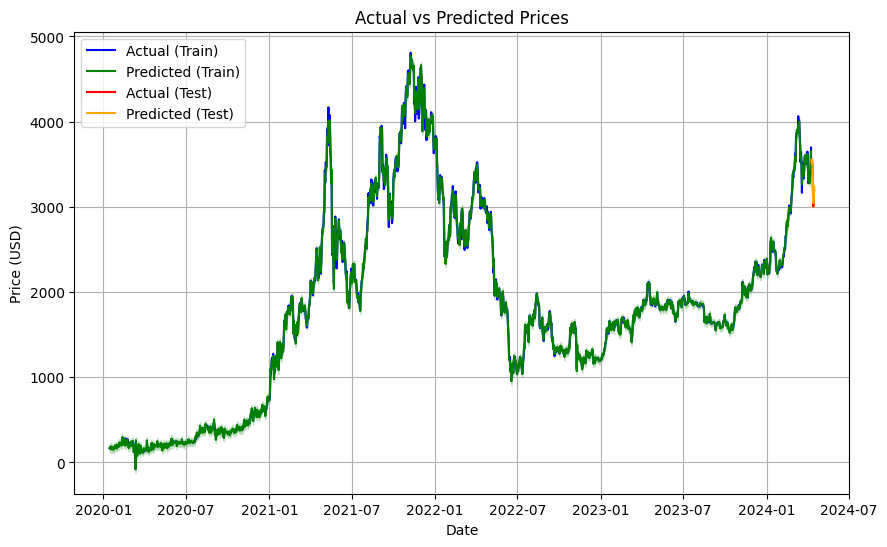

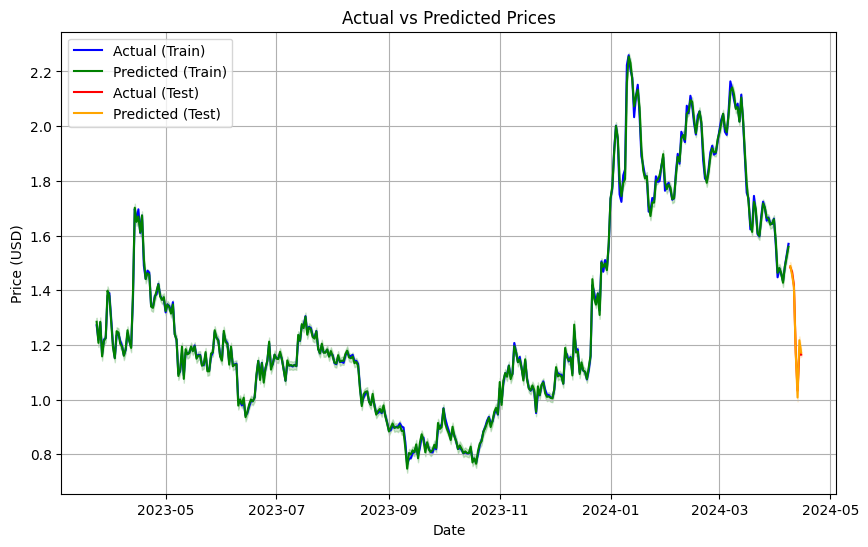

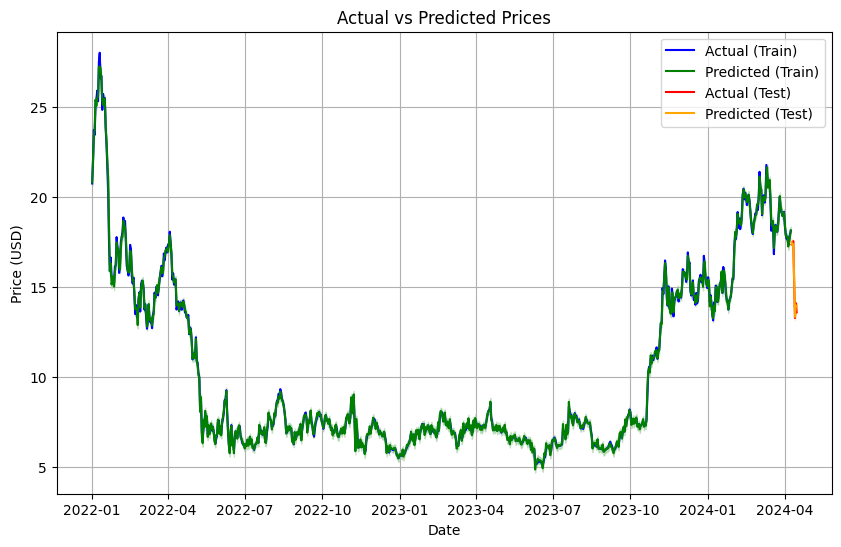

7-Day Ethereum Price Forecast:
             ds         yhat                  price_range
1553 2024-04-16  3233.730812  ETHPriceRanges.pr_3225_3250
1554 2024-04-17  3235.075236  ETHPriceRanges.pr_3225_3250
1555 2024-04-18  3230.976148  ETHPriceRanges.pr_3225_3250
1556 2024-04-19  3235.919536  ETHPriceRanges.pr_3225_3250
1557 2024-04-20  3239.069490  ETHPriceRanges.pr_3225_3250
1558 2024-04-21  3244.839020  ETHPriceRanges.pr_3225_3250
1559 2024-04-22  3244.516736  ETHPriceRanges.pr_3225_3250

7-Day Arbitrum Price Forecast:
            ds      yhat                price_range
389 2024-04-16  1.165748  ARBPriceRanges.pr_1_1_1_2
390 2024-04-17  1.165940  ARBPriceRanges.pr_1_1_1_2
391 2024-04-18  1.160503  ARBPriceRanges.pr_1_1_1_2
392 2024-04-19  1.158264  ARBPriceRanges.pr_1_1_1_2
393 2024-04-20  1.160130  ARBPriceRanges.pr_1_1_1_2
394 2024-04-21  1.158269  ARBPriceRanges.pr_1_1_1_2
395 2024-04-22  1.160528  ARBPriceRanges.pr_1_1_1_2

7-Day Chainlink Price Forecast:
            ds       yha

In [ ]:
from enum import Enum
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

class ETHPriceRanges(Enum):
    pr_2000_2025 = 1
    pr_2025_2050 = 2
    pr_2050_2075 = 3
    pr_2075_2100 = 4
    pr_2100_2125 = 5
    pr_2125_2150 = 6
    pr_2150_2175 = 7
    pr_2175_2200 = 8
    pr_2200_2225 = 9
    pr_2225_2250 = 10
    pr_2250_2275 = 11
    pr_2275_2300 = 12
    pr_2300_2325 = 13
    pr_2325_2350 = 14
    pr_2350_2375 = 15
    pr_2375_2400 = 16
    pr_2400_2425 = 17
    pr_2425_2450 = 18
    pr_2450_2475 = 19
    pr_2475_2500 = 20
    pr_2500_2525 = 21
    pr_2525_2550 = 22
    pr_2550_2575 = 23
    pr_2575_2600 = 24
    pr_2600_2625 = 25
    pr_2625_2650 = 26
    pr_2650_2675 = 27
    pr_2675_2700 = 28
    pr_2700_2725 = 29
    pr_2725_2750 = 30
    pr_2750_2775 = 31
    pr_2775_2800 = 32
    pr_2800_2825 = 33
    pr_2825_2850 = 34
    pr_2850_2875 = 35
    pr_2875_2900 = 36
    pr_2900_2925 = 37
    pr_2925_2950 = 38
    pr_2950_2975 = 39
    pr_2975_3000 = 40
    pr_3000_3025 = 41
    pr_3025_3050 = 42
    pr_3050_3075 = 43
    pr_3075_3100 = 44
    pr_3100_3125 = 45
    pr_3125_3150 = 46
    pr_3150_3175 = 47
    pr_3175_3200 = 48
    pr_3200_3225 = 49
    pr_3225_3250 = 50
    pr_3250_3275 = 51
    pr_3275_3300 = 52
    pr_3300_3325 = 53
    pr_3325_3350 = 54
    pr_3350_3375 = 55
    pr_3375_3400 = 56
    pr_3400_3425 = 57
    pr_3425_3450 = 58
    pr_3450_3475 = 59
    pr_3475_3500 = 60
    pr_3500_3525 = 61
    pr_3525_3550 = 62
    pr_3550_3575 = 63
    pr_3575_3600 = 64
    pr_3600_3625 = 65
    pr_3625_3650 = 66
    pr_3650_3675 = 67
    pr_3675_3700 = 68
    pr_3700_3725 = 69
    pr_3725_3750 = 70
    pr_3750_3775 = 71
    pr_3775_3800 = 72
    pr_3800_3825 = 73
    pr_3825_3850 = 74
    pr_3850_3875 = 75
    pr_3875_3900 = 76
    pr_3900_3925 = 77
    pr_3925_3950 = 78
    pr_3950_3975 = 79
    pr_3975_4000 = 80

class ARBPriceRanges(Enum):
    pr_0_5_0_6 = 1
    pr_0_6_0_7 = 2
    pr_0_7_0_8 = 3
    pr_0_8_0_9 = 4
    pr_0_9_1_0 = 5
    pr_1_0_1_1 = 6
    pr_1_1_1_2 = 7
    pr_1_2_1_3 = 8
    pr_1_3_1_4 = 9
    pr_1_4_1_5 = 10
    pr_1_5_1_6 = 11
    pr_1_6_1_7 = 12
    pr_1_7_1_8 = 13
    pr_1_8_1_9 = 14
    pr_1_9_2_0 = 15
    pr_2_0_2_1 = 16
    pr_2_1_2_2 = 17
    pr_2_2_2_3 = 18
    pr_2_3_2_4 = 19
    pr_2_4_2_5 = 20
    pr_2_5_2_6 = 21
    pr_2_6_2_7 = 22
    pr_2_7_2_8 = 23
    pr_2_8_2_9 = 24
    pr_2_9_3_0 = 25

class LINKPriceRanges(Enum):
    pr_4_6 = 1
    pr_6_8 = 2
    pr_8_10 = 3
    pr_10_12 = 4
    pr_12_14 = 5
    pr_14_16 = 6
    pr_16_18 = 7
    pr_18_20 = 8
    pr_20_22 = 9
    pr_22_24 = 10
    pr_24_26 = 11

def load_data(file_path):
    df = pd.read_csv(file_path, index_col='Date', parse_dates=['Date'], dayfirst=True)
    df = df.reindex(index=df.index[::-1])
    return df

def prepare_data(df):
    df_prophet = df.reset_index()
    df_prophet = df_prophet.rename(columns={'Date': 'ds', 'Price': 'y', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Vol.': 'volume', 'Change %': 'change_percent'})

    # Convert columns to the correct data types
    df_prophet['y'] = df_prophet['y'].astype(str).str.replace(',', '').astype(float)
    df_prophet['open'] = df_prophet['open'].astype(str).str.replace(',', '').astype(float)
    df_prophet['high'] = df_prophet['high'].astype(str).str.replace(',', '').astype(float)
    df_prophet['low'] = df_prophet['low'].astype(str).str.replace(',', '').astype(float)

    import re

    def convert_volume(value):
        if isinstance(value, str):
            if value.endswith('M'):
                return float(value[:-1]) * 1e6
            elif value.endswith('K'):
                return float(value[:-1]) * 1e3
            elif value.endswith('B'):
                return float(value[:-1]) * 1e9
            else:
                return float(value)
        else:
            return value

    df_prophet['volume'] = df_prophet['volume'].apply(convert_volume)
    df_prophet['change_percent'] = df_prophet['change_percent'].str.replace('%', '').str.replace(',', '').astype(float)
    return df_prophet

def create_model():
    model = Prophet(
        changepoint_prior_scale=10,
        holidays_prior_scale=15,
        seasonality_mode='multiplicative',
        seasonality_prior_scale=30,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True
    )
    model.add_country_holidays(country_name='US')
    model.add_regressor('open')
    model.add_regressor('high')
    model.add_regressor('low')
    model.add_regressor('volume')
    model.add_regressor('change_percent')
    return model

def evaluate_model(df_prophet, model):
    train_data = df_prophet[:-7]
    test_data = df_prophet[-7:]
    train_forecast = model.predict(train_data)
    test_forecast = model.predict(test_data)

    train_mae = mean_absolute_error(train_data['y'], train_forecast['yhat'])
    train_mse = mean_squared_error(train_data['y'], train_forecast['yhat'])
    train_r2 = r2_score(train_data['y'], train_forecast['yhat'])

    test_mae = mean_absolute_error(test_data['y'], test_forecast['yhat'])
    test_mse = mean_squared_error(test_data['y'], test_forecast['yhat'])
    test_r2 = r2_score(test_data['y'], test_forecast['yhat'])

    print(f"Train MAE: {train_mae:.2f}")
    print(f"Train MSE: {train_mse:.2f}")
    print(f"Train R-squared: {train_r2:.2f}")
    print(f"Test MAE: {test_mae:.2f}")
    print(f"Test MSE: {test_mse:.2f}")
    print(f"Test R-squared: {test_r2:.2f}")

    return train_data, test_data, train_forecast, test_forecast

def make_forecast(df_prophet, model, periods=7):
    future = model.make_future_dataframe(periods=periods)
    future['open'] = df_prophet['open'].iloc[-1]
    future['high'] = df_prophet['high'].iloc[-1]
    future['low'] = df_prophet['low'].iloc[-1]
    future['volume'] = df_prophet['volume'].iloc[-1]
    future['change_percent'] = df_prophet['change_percent'].iloc[-1]
    forecast = model.predict(future)
    return forecast

def plot_actual_vs_predicted(train_data, test_data, train_forecast, test_forecast):
    plt.figure(figsize=(10, 6))
    plt.plot(train_data['ds'], train_data['y'], label='Actual (Train)', color='blue')
    plt.plot(train_data['ds'], train_forecast['yhat'], label='Predicted (Train)', color='green')
    plt.plot(test_data['ds'], test_data['y'], label='Actual (Test)', color='red')
    plt.plot(test_data['ds'], test_forecast['yhat'], label='Predicted (Test)', color='orange')
    plt.fill_between(train_data['ds'], train_forecast['yhat_lower'], train_forecast['yhat_upper'], color='green', alpha=0.2)
    plt.fill_between(test_data['ds'], test_forecast['yhat_lower'], test_forecast['yhat_upper'], color='orange', alpha=0.2)
    plt.xlabel('Date')
    plt.ylabel('Price (USD)')
    plt.title('Actual vs Predicted Prices')
    plt.legend()
    plt.grid(True)
    plt.show()

def price_to_range(price):
    if 2000 <= price < 2025:
        return ETHPriceRanges.pr_2000_2025
    elif 2025 <= price < 2050:
        return ETHPriceRanges.pr_2025_2050
    elif 2050 <= price < 2075:
        return ETHPriceRanges.pr_2050_2075
    elif 2075 <= price < 2100:
        return ETHPriceRanges.pr_2075_2100
    elif 2100 <= price < 2125:
        return ETHPriceRanges.pr_2100_2125
    elif 2125 <= price < 2150:
        return ETHPriceRanges.pr_2125_2150
    elif 2150 <= price < 2175:
        return ETHPriceRanges.pr_2150_2175
    elif 2175 <= price < 2200:
        return ETHPriceRanges.pr_2175_2200
    elif 2200 <= price < 2225:
        return ETHPriceRanges.pr_2200_2225
    elif 2225 <= price < 2250:
        return ETHPriceRanges.pr_2225_2250
    elif 2250 <= price < 2275:
        return ETHPriceRanges.pr_2250_2275
    elif 2275 <= price < 2300:
        return ETHPriceRanges.pr_2275_2300
    elif 2300 <= price < 2325:
        return ETHPriceRanges.pr_2300_2325
    elif 2325 <= price < 2350:
        return ETHPriceRanges.pr_2325_2350
    elif 2350 <= price < 2375:
        return ETHPriceRanges.pr_2350_2375
    elif 2375 <= price < 2400:
        return ETHPriceRanges.pr_2375_2400
    elif 2400 <= price < 2425:
        return ETHPriceRanges.pr_2400_2425
    elif 2425 <= price < 2450:
        return ETHPriceRanges.pr_2425_2450
    elif 2450 <= price < 2475:
        return ETHPriceRanges.pr_2450_2475
    elif 2475 <= price < 2500:
        return ETHPriceRanges.pr_2475_2500
    elif 2500 <= price < 2525:
        return ETHPriceRanges.pr_2500_2525
    elif 2525 <= price < 2550:
        return ETHPriceRanges.pr_2525_2550
    elif 2550 <= price < 2575:
        return ETHPriceRanges.pr_2550_2575
    elif 2575 <= price < 2600:
        return ETHPriceRanges.pr_2575_2600
    elif 2600 <= price < 2625:
        return ETHPriceRanges.pr_2600_2625
    elif 2625 <= price < 2650:
        return ETHPriceRanges.pr_2625_2650
    elif 2650 <= price < 2675:
        return ETHPriceRanges.pr_2650_2675
    elif 2675 <= price < 2700:
        return ETHPriceRanges.pr_2675_2700
    elif 2700 <= price < 2725:
        return ETHPriceRanges.pr_2700_2725
    elif 2725 <= price < 2750:
        return ETHPriceRanges.pr_2725_2750
    elif 2750 <= price < 2775:
        return ETHPriceRanges.pr_2750_2775
    elif 2775 <= price < 2800:
        return ETHPriceRanges.pr_2775_2800
    elif 2800 <= price < 2825:
        return ETHPriceRanges.pr_2800_2825
    elif 2825 <= price < 2850:
        return ETHPriceRanges.pr_2825_2850
    elif 2850 <= price < 2875:
        return ETHPriceRanges.pr_2850_2875
    elif 2875 <= price < 2900:
        return ETHPriceRanges.pr_2875_2900
    elif 2900 <= price < 2925:
        return ETHPriceRanges.pr_2900_2925
    elif 2925 <= price < 2950:
        return ETHPriceRanges.pr_2925_2950
    elif 2950 <= price < 2975:
        return ETHPriceRanges.pr_2950_2975
    elif 2975 <= price < 3000:
        return ETHPriceRanges.pr_2975_3000
    elif 3000 <= price < 3025:
        return ETHPriceRanges.pr_3000_3025
    elif 3025 <= price < 3050:
        return ETHPriceRanges.pr_3025_3050
    elif 3050 <= price < 3075:
        return ETHPriceRanges.pr_3050_3075
    elif 3075 <= price < 3100:
        return ETHPriceRanges.pr_3075_3100
    elif 3100 <= price < 3125:
        return ETHPriceRanges.pr_3100_3125
    elif 3125 <= price < 3150:
        return ETHPriceRanges.pr_3125_3150
    elif 3150 <= price < 3175:
        return ETHPriceRanges.pr_3150_3175
    elif 3175 <= price < 3200:
        return ETHPriceRanges.pr_3175_3200
    elif 3200 <= price < 3225:
        return ETHPriceRanges.pr_3200_3225
    elif 3225 <= price < 3250:
        return ETHPriceRanges.pr_3225_3250
    elif 3250 <= price < 3275:
        return ETHPriceRanges.pr_3250_3275
    elif 3275 <= price < 3300:
        return ETHPriceRanges.pr_3275_3300
    elif 3300 <= price < 3325:
        return ETHPriceRanges.pr_3300_3325
    elif 3325 <= price < 3350:
        return ETHPriceRanges.pr_3325_3350
    elif 3350 <= price < 3375:
        return ETHPriceRanges.pr_3350_3375
    elif 3375 <= price < 3400:
        return ETHPriceRanges.pr_3375_3400
    elif 3400 <= price < 3425:
        return ETHPriceRanges.pr_3400_3425
    elif 3425 <= price < 3450:
        return ETHPriceRanges.pr_3425_3450
    elif 3450 <= price < 3475:
        return ETHPriceRanges.pr_3450_3475
    elif 3475 <= price < 3500:
        return ETHPriceRanges.pr_3475_3500
    elif 3500 <= price < 3525:
        return ETHPriceRanges.pr_3500_3525
    elif 3525 <= price < 3550:
        return ETHPriceRanges.pr_3525_3550
    elif 3550 <= price < 3575:
        return ETHPriceRanges.pr_3550_3575
    elif 3575 <= price < 3600:
        return ETHPriceRanges.pr_3575_3600
    elif 3600 <= price < 3625:
        return ETHPriceRanges.pr_3600_3625
    elif 3625 <= price < 3650:
        return ETHPriceRanges.pr_3625_3650
    elif 3650 <= price < 3675:
        return ETHPriceRanges.pr_3650_3675
    elif 3675 <= price < 3700:
        return ETHPriceRanges.pr_3675_3700
    elif 3700 <= price < 3725:
        return ETHPriceRanges.pr_3700_3725
    elif 3725 <= price < 3750:
        return ETHPriceRanges.pr_3725_3750
    elif 3750 <= price < 3775:
        return ETHPriceRanges.pr_3750_3775
    elif 3775 <= price < 3800:
        return ETHPriceRanges.pr_3775_3800
    elif 3800 <= price < 3825:
        return ETHPriceRanges.pr_3800_3825
    elif 3825 <= price < 3850:
        return ETHPriceRanges.pr_3825_3850
    elif 3850 <= price < 3875:
        return ETHPriceRanges.pr_3850_3875
    elif 3875 <= price < 3900:
        return ETHPriceRanges.pr_3875_3900
    elif 3900 <= price < 3925:
        return ETHPriceRanges.pr_3900_3925
    elif 3925 <= price < 3950:
        return ETHPriceRanges.pr_3925_3950
    elif 3950 <= price < 3975:
        return ETHPriceRanges.pr_3950_3975
    elif 3975 <= price < 4000:
        return ETHPriceRanges.pr_3975_4000
    else:
        return None

def price_to_range_arb(price):
    if 0.5 <= price < 0.6:
        return ARBPriceRanges.pr_0_5_0_6
    elif 0.6 <= price < 0.7:
        return ARBPriceRanges.pr_0_6_0_7
    elif 0.7 <= price < 0.8:
        return ARBPriceRanges.pr_0_7_0_8
    elif 0.8 <= price < 0.9:
        return ARBPriceRanges.pr_0_8_0_9
    elif 0.9 <= price < 1.0:
        return ARBPriceRanges.pr_0_9_1_0
    elif 1.0 <= price < 1.1:
        return ARBPriceRanges.pr_1_0_1_1
    elif 1.1 <= price < 1.2:
        return ARBPriceRanges.pr_1_1_1_2
    elif 1.2 <= price < 1.3:
        return ARBPriceRanges.pr_1_2_1_3
    elif 1.3 <= price < 1.4:
        return ARBPriceRanges.pr_1_3_1_4
    elif 1.4 <= price < 1.5:
        return ARBPriceRanges.pr_1_4_1_5
    elif 1.5 <= price < 1.6:
        return ARBPriceRanges.pr_1_5_1_6
    elif 1.6 <= price < 1.7:
        return ARBPriceRanges.pr_1_6_1_7
    elif 1.7 <= price < 1.8:
        return ARBPriceRanges.pr_1_7_1_8
    elif 1.8 <= price < 1.9:
        return ARBPriceRanges.pr_1_8_1_9
    elif 1.9 <= price < 2.0:
        return ARBPriceRanges.pr_1_9_2_0
    elif 2.0 <= price < 2.1:
        return ARBPriceRanges.pr_2_0_2_1
    elif 2.1 <= price < 2.2:
        return ARBPriceRanges.pr_2_1_2_2
    elif 2.2 <= price < 2.3:
        return ARBPriceRanges.pr_2_2_2_3
    elif 2.3 <= price < 2.4:
        return ARBPriceRanges.pr_2_3_2_4
    elif 2.4 <= price < 2.5:
        return ARBPriceRanges.pr_2_4_2_5
    elif 2.5 <= price < 2.6:
        return ARBPriceRanges.pr_2_5_2_6
    elif 2.6 <= price < 2.7:
        return ARBPriceRanges.pr_2_6_2_7
    elif 2.7 <= price < 2.8:
        return ARBPriceRanges.pr_2_7_2_8
    elif 2.8 <= price < 2.9:
        return ARBPriceRanges.pr_2_8_2_9
    elif 2.9 <= price < 3.0:
        return ARBPriceRanges.pr_2_9_3_0
    else:
        return None

def price_to_range_link(price):
    if 4 <= price < 6:
        return LINKPriceRanges.pr_4_6
    elif 6 <= price < 8:
        return LINKPriceRanges.pr_6_8
    elif 8 <= price < 10:
        return LINKPriceRanges.pr_8_10
    elif 10 <= price < 12:
        return LINKPriceRanges.pr_10_12
    elif 12 <= price < 14:
        return LINKPriceRanges.pr_12_14
    elif 14 <= price < 16:
        return LINKPriceRanges.pr_14_16
    elif 16 <= price < 18:
        return LINKPriceRanges.pr_16_18
    elif 18 <= price < 20:
        return LINKPriceRanges.pr_18_20
    elif 20 <= price < 22:
        return LINKPriceRanges.pr_20_22
    elif 22 <= price < 24:
        return LINKPriceRanges.pr_22_24
    elif 24 <= price < 26:
        return LINKPriceRanges.pr_24_26
    else:
        return None

def get_price_range(yhat_value):
    lower_bound = round(yhat_value / 25) * 25
    upper_bound = lower_bound + 25
    return f"{lower_bound}-{upper_bound}"

# Load and prepare data
ethereum_df = load_data('/content/Ethereum Historical Data.csv')
ethereum_df_prophet = prepare_data(ethereum_df)
arbitrum_df = load_data('/content/Arbitrum Historical Data.csv')
arbitrum_df_prophet = prepare_data(arbitrum_df)
chainlink_df = load_data('/content/Chainlink Historical Data.csv')
chainlink_df_prophet = prepare_data(chainlink_df)

# Create and fit the models
ethereum_model = create_model()
ethereum_model.fit(ethereum_df_prophet)
arbitrum_model = create_model()
arbitrum_model.fit(arbitrum_df_prophet)
chainlink_model = create_model()
chainlink_model.fit(chainlink_df_prophet)

# Evaluate the models
ethereum_train_data, ethereum_test_data, ethereum_train_forecast, ethereum_test_forecast = evaluate_model(ethereum_df_prophet, ethereum_model)
arbitrum_train_data, arbitrum_test_data, arbitrum_train_forecast, arbitrum_test_forecast = evaluate_model(arbitrum_df_prophet, arbitrum_model)
chainlink_train_data, chainlink_test_data, chainlink_train_forecast, chainlink_test_forecast = evaluate_model(chainlink_df_prophet, chainlink_model)

# Make the forecasts
ethereum_forecast = make_forecast(ethereum_df_prophet, ethereum_model)
arbitrum_forecast = make_forecast(arbitrum_df_prophet, arbitrum_model)
chainlink_forecast = make_forecast(chainlink_df_prophet, chainlink_model)

# Plot the actual vs predicted data
plot_actual_vs_predicted(ethereum_train_data, ethereum_test_data, ethereum_train_forecast, ethereum_test_forecast)
plot_actual_vs_predicted(arbitrum_train_data, arbitrum_test_data, arbitrum_train_forecast, arbitrum_test_forecast)
plot_actual_vs_predicted(chainlink_train_data, chainlink_test_data, chainlink_train_forecast, chainlink_test_forecast)

# Display the 7-day forecasts
print("7-Day Ethereum Price Forecast:")
ethereum_forecast['price_range'] = ethereum_forecast['yhat'].apply(price_to_range)
print(ethereum_forecast[['ds', 'yhat', 'price_range']][-7:])

print("\n7-Day Arbitrum Price Forecast:")
arbitrum_forecast['price_range'] = arbitrum_forecast['yhat'].apply(price_to_range_arb)
print(arbitrum_forecast[['ds', 'yhat', 'price_range']][-7:])

print("\n7-Day Chainlink Price Forecast:")
chainlink_forecast['price_range'] = chainlink_forecast['yhat'].apply(price_to_range_link)
print(chainlink_forecast[['ds', 'yhat', 'price_range']][-7:])